# Session 14 — Conformal Prediction: Implementation 🏥


> *Wrapping a trained DenseNet121 in a coverage guarantee — and testing whether it actually holds where it matters.*

---

### 🎯 What this notebook does

Conformal Prediction (CP) takes a fundamentally different view of uncertainty. Instead of estimating Bayesian uncertainty directly, CP wraps a standard classifier with a statistical framework that produces prediction sets with formal finite-sample coverage guarantees. Rather than saying “the model is uncertain,” CP asks: *which labels can we safely exclude while still guaranteeing coverage?*

The notebook walks through the full Split Conformal Prediction pipeline step by step:

* **Data loading and preprocessing** — prepare chest X-rays, apply MONAI transforms, and preserve realistic class imbalance through controlled subsampling
* **Training the base DenseNet121 model** — train a standard deterministic classifier using cross-entropy loss with early stopping and learning-rate scheduling
* **The Split Conformal procedure** — use a held-out calibration set to convert the DenseNet121 classifier into a prediction-set model with formal coverage guarantees. Instead of producing only a single prediction, the model outputs a set of plausible labels whose size adapts to uncertainty while ensuring the true label is included with probability at least (1-$\alpha$).
* **Measuring base model performance** — evaluate the underlying DenseNet121 using accuracy and AUC-ROC on the held-out test set
* **Constructing prediction sets on the test set** — generate singleton, empty, or multi-label prediction sets depending on model confidence
* **Statistical comparison between certain and uncertain cases** — compare predictive performance between singleton prediction sets (certain) and ambiguous/full prediction sets (uncertain)
* **Visualization of the most certain and most uncertain chest X-rays** — inspect representative cases with clinical-style interpretation of conformal behaviour and prediction-set structure

<div align="center" style="margin-top: 50px;"> <img src="intro.png" width="700" /> </div>

---
## 📦 Part 1 — Installs and imports

In [53]:
!pip install -q monai torch-uncertainty lightning

import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture

# MONAI
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RepeatChanneld,
    ScaleIntensityd, Resized, RandFlipd, RandRotated, EnsureTyped,
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121

# Torch-Uncertainty
from torch_uncertainty.layers.bayesian import BayesLinear
from torch_uncertainty.losses import ELBOLoss
from torch_uncertainty.metrics.classification import CalibrationError, AURC

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


---
## 🗂️ Part 2 — Data preparation

Same splits as previous sessions, **plus a held-out calibration set** that CP requires.

We carve the calibration set from the training data — 20% of train becomes calibration. The base model is trained on the remaining 80%. This is the standard split conformal setup.

In [54]:
DATA_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

def is_grayscale(path):
    try:
        return Image.open(path).mode in ['L', 'I;16', 'I']
    except:
        return False

def make_split_list_filtered(split_dir):
    normal_files = sorted(glob.glob(os.path.join(split_dir, 'NORMAL', '*')))
    pneu_files   = sorted(glob.glob(os.path.join(split_dir, 'PNEUMONIA', '*')))

    normal_files = [f for f in normal_files if is_grayscale(f)]
    pneu_files   = [f for f in pneu_files if is_grayscale(f)]

    return (
        [{'image': f, 'label': 0} for f in normal_files] +
        [{'image': f, 'label': 1} for f in pneu_files]
    )

def subsample_with_ratio(files, n_total, normal_pneu_ratio, seed=42):

    rng = np.random.default_rng(seed)

    normal = [d for d in files if int(d['label']) == 0]
    pneu   = [d for d in files if int(d['label']) == 1]

    rng.shuffle(normal)
    rng.shuffle(pneu)

    n_pneu   = int(round(n_total / (1 + normal_pneu_ratio)))
    n_normal = n_total - n_pneu

    n_normal = min(n_normal, len(normal))
    n_pneu   = min(n_pneu, len(pneu))

    subset = normal[:n_normal] + pneu[:n_pneu]

    rng.shuffle(subset)

    print(
        f'  NORMAL={n_normal}, '
        f'PNEUMONIA={n_pneu}, '
        f'total={len(subset)}, '
        f'ratio={n_normal/n_pneu:.2f}'
    )

    return subset

# Load dataset splits
train_files_all = make_split_list_filtered(
    os.path.join(DATA_DIR, 'train')
)

val_files_all = make_split_list_filtered(
    os.path.join(DATA_DIR, 'val')
)

test_files_all = make_split_list_filtered(
    os.path.join(DATA_DIR, 'test')
)

# Subsample train set
print('Full train set (normal:pneu = 2.7:1):')

all_train = subsample_with_ratio(
    train_files_all,
    n_total=1000,
    normal_pneu_ratio=2.7,
    seed=SEED
)

# Stratified train/calibration split
labels = [x['label'] for x in all_train]

train_files, cal_files = train_test_split(
    all_train,
    test_size=0.20,          # 20% calibration set
    stratify=labels,         # preserve class ratio
    random_state=SEED,
    shuffle=True
)

print(f'\nAfter CP train/calibration split:')
print(f'  Train set  : {len(train_files)} samples')
print(f'  Cal set    : {len(cal_files)} samples  ← CP calibration set')

# Test set
print('\nTest (normal:pneu = 1.7:1):')

test_files = subsample_with_ratio(
    test_files_all,
    n_total=100,
    normal_pneu_ratio=1.7,
    seed=SEED
)

print(f'Val (full): {len(val_files_all)}')

Full train set (normal:pneu = 2.7:1):
  NORMAL=730, PNEUMONIA=270, total=1000, ratio=2.70

After CP train/calibration split:
  Train set  : 800 samples
  Cal set    : 200 samples  ← CP calibration set

Test (normal:pneu = 1.7:1):
  NORMAL=63, PNEUMONIA=37, total=100, ratio=1.70
Val (full): 16


In [55]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandRotated(keys=['image'], prob=0.3, range_x=0.12),
    EnsureTyped(keys=['image', 'label']),
])
eval_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    EnsureTyped(keys=['image', 'label']),
])

train_ds = Dataset(data=train_files,   transform=train_tfms)
cal_ds   = Dataset(data=cal_files,     transform=eval_tfms)
val_ds   = Dataset(data=val_files_all, transform=eval_tfms)
test_ds  = Dataset(data=test_files,    transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
cal_loader   = DataLoader(cal_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

---
## 🧠 Part 3 — Train the base model

Standard DenseNet121 — same architecture as previous sessions. No uncertainty modifications. CP wraps it afterwards.

In [80]:
# Standard DenseNet121 training

EARLY_STOP_PATIENCE = 10
PLATEAU_PATIENCE    = 3
PLATEAU_FACTOR      = 0.5
MIN_LR              = 1e-6

BEST_PATH = "/kaggle/working/best_model.pth"

# Model

base_model = DenseNet121(
    spatial_dims=2,
    in_channels=3,
    out_channels=2,
    pretrained=True,
).to(device)

# Freeze backbone

for name, param in base_model.named_parameters():

    if 'class_layers' not in name:

        param.requires_grad = False

# Training setup

NUM_EPOCHS = 100

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, base_model.parameters()),
    lr=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE,
    threshold=1e-3,
    threshold_mode='rel',
    min_lr=MIN_LR,
)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': [],
    'lr': []
}

# Early stopping variables

best_val_loss = np.inf

best_epoch = 0

epochs_no_improve = 0

# Training loop

for epoch in range(1, NUM_EPOCHS + 1):

    # Train

    base_model.train()

    epoch_loss = 0.0

    for batch in tqdm(
        train_loader,
        desc=f'Epoch {epoch:02d}/{NUM_EPOCHS}',
        leave=False
    ):

        images = batch['image'].to(
            device,
            dtype=torch.float32
        )

        labels = batch['label'].to(
            device,
            dtype=torch.long
        )

        optimizer.zero_grad()

        logits = base_model(images)

        loss = loss_fn(logits, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation

    base_model.eval()

    val_loss = 0.0

    val_probs  = []
    val_preds  = []
    val_labels = []

    with torch.no_grad():

        for batch in val_loader:

            images = batch['image'].to(
                device,
                dtype=torch.float32
            )

            labels_tensor = batch['label'].to(
                device,
                dtype=torch.long
            )

            logits = base_model(images)

            loss = loss_fn(logits, labels_tensor)

            val_loss += loss.item()

            probs = torch.softmax(
                logits,
                dim=-1
            ).cpu().numpy()

            labels = labels_tensor.cpu().numpy()

            val_probs.extend(probs[:, 1].tolist())

            val_preds.extend(
                probs.argmax(1).tolist()
            )

            val_labels.extend(labels.tolist())

    avg_val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    # Scheduler step

    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    # Save history

    history['train_loss'].append(avg_train_loss)

    history['val_loss'].append(avg_val_loss)

    history['val_acc'].append(val_acc)

    history['val_auc'].append(val_auc)

    history['lr'].append(current_lr)

    # Save latest model

    '''torch.save(
        base_model.state_dict(),
        LATEST_PATH
    )

    print(f'Latest model saved to: {LATEST_PATH}')'''

    # Save best model

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_epoch = epoch

        torch.save(
            base_model.state_dict(),
            BEST_PATH
        )

        epochs_no_improve = 0

        print(
            f'✅ Saved best model '
            f'(val_loss={best_val_loss:.4f})'
        )

    else:

        epochs_no_improve += 1

    # Print progress

    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_val_loss:.4f} | '
        f'Val Acc: {val_acc:.3f} | '
        f'Val AUC: {val_auc:.3f} | '
        f'LR: {current_lr:.6f}'
    )

    # Early stopping

    if epochs_no_improve >= EARLY_STOP_PATIENCE:

        print()

        print('🛑 Early stopping triggered')

        break

print('\nTraining complete ✅')

print(f'Best model saved to: {BEST_PATH}')

✅ Saved best model (val_loss=0.4819)
Epoch 01/100 | Train Loss: 0.4394 | Val Loss: 0.4819 | Val Acc: 0.750 | Val AUC: 0.906 | LR: 0.001000


✅ Saved best model (val_loss=0.4050)
Epoch 02/100 | Train Loss: 0.3117 | Val Loss: 0.4050 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.001000


Epoch 03/100 | Train Loss: 0.2309 | Val Loss: 0.4053 | Val Acc: 0.812 | Val AUC: 0.938 | LR: 0.001000


Epoch 04/100 | Train Loss: 0.1901 | Val Loss: 0.4349 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.001000


Epoch 05/100 | Train Loss: 0.1687 | Val Loss: 0.4287 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.001000


...

Epoch 08/100 | Train Loss: 0.1541 | Val Loss: 0.4750 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.000500


Epoch 09/100 | Train Loss: 0.1583 | Val Loss: 0.4781 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.000500


Epoch 10/100 | Train Loss: 0.1498 | Val Loss: 0.4562 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.000250


Epoch 11/100 | Train Loss: 0.1424 | Val Loss: 0.4698 | Val Acc: 0.812 | Val AUC: 0.875 | LR: 0.000250


Epoch 12/100 | Train Loss: 0.1415 | Val Loss: 0.4534 | Val Acc: 0.812 | Val AUC: 0.906 | LR: 0.000250

🛑 Early stopping triggered

Training complete ✅
Best model saved to: /kaggle/working/best_model.pth


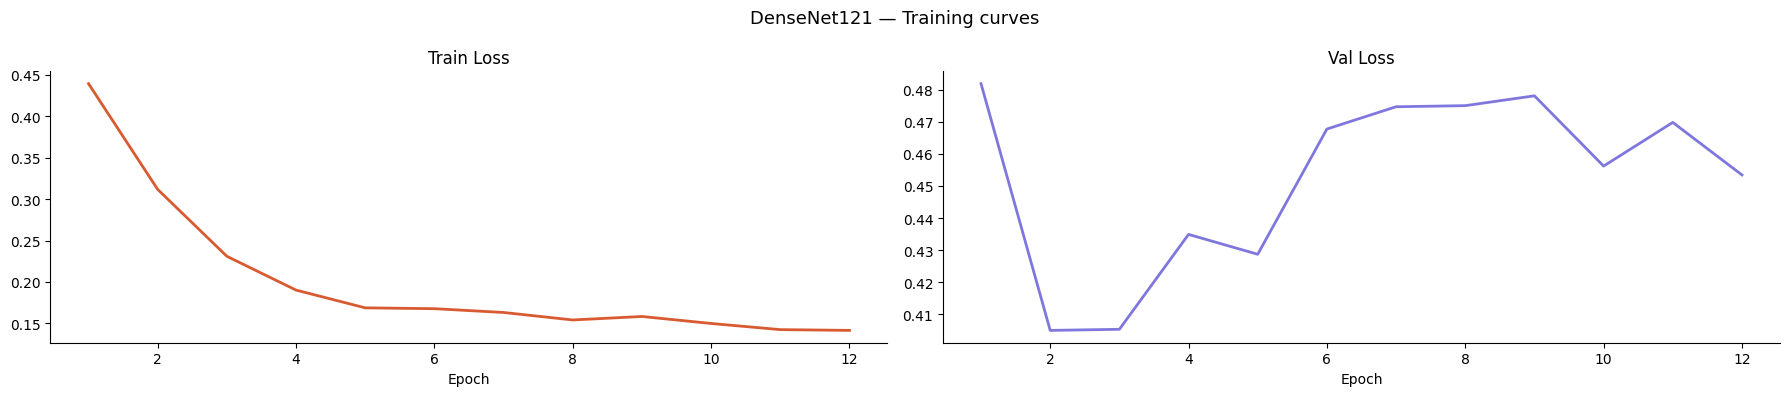

In [81]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle('DenseNet121 — Training curves', fontsize=13)

epochs = range(1, len(history['train_loss']) + 1)

plot_config = [
    ('train_loss', '#D85A30', 'Train Loss'),
    ('val_loss',   '#7F77DD', 'Val Loss')
]

for ax, (key, color, title) in zip(axes, plot_config):
    ax.plot(epochs, history[key], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 📈 Part 4 — Evaluate the base model on test set

The best-trained model is evaluated on the test set in inference mode

In [82]:
# Load best saved model

BEST_PATH = "/kaggle/input/models/benyamingheiji/cp-best-model/pytorch/default/1/cp_best_model.pth"

base_model = DenseNet121(
    spatial_dims=2,
    in_channels=3,
    out_channels=2,
    pretrained=True,
).to(device)

base_model.load_state_dict(
    torch.load(BEST_PATH, map_location=device)
)

base_model.eval()

print('✅ Best model loaded successfully')

✅ Best model loaded successfully


In [83]:
test_probs  = []
test_preds  = []
test_labels = []

with torch.no_grad():

    for batch in test_loader:

        images = batch['image'].to(device, dtype=torch.float32)
        labels = batch['label'].to(device, dtype=torch.long)

        logits = base_model(images)

        probs = torch.softmax(logits, dim=-1)

        preds = probs.argmax(dim=1)

        test_probs.extend(probs[:, 1].cpu().tolist())
        test_preds.extend(preds.cpu().tolist())
        test_labels.extend(labels.cpu().tolist())

# Metrics
test_acc = accuracy_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print(f'Test Accuracy: {test_acc:.3f}')
print(f'Test AUC     : {test_auc:.3f}')

Test Accuracy: 0.870
Test AUC     : 0.926


---
## 🔧 Part 5 — The split conformal procedure

Three functions implement the full CP pipeline:
1. `compute_cal_scores` — nonconformity scores on the calibration set
2. `compute_threshold` — the $(1-\alpha)$ quantile with the $+1$ finite-sample correction
3. `make_prediction_sets` — wrap any test input in a guaranteed prediction set

In [84]:
def compute_cal_scores(model, cal_loader, device=device):
    """
    Compute nonconformity scores on the calibration set.
    Score s(x,y) = 1 - p̂_y(x): how surprising is the true label?

    Returns:
        cal_scores : array [n_cal] — one score per calibration example
        cal_labels : array [n_cal] — true labels
        cal_probs  : array [n_cal, K] — softmax probabilities
    """
    model.eval()
    all_scores, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(cal_loader, desc='Computing calibration scores'):
            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].cpu().numpy()
            probs  = torch.softmax(model(images), dim=-1).cpu().numpy()

            # Nonconformity score: 1 - probability assigned to true class
            scores = 1 - probs[np.arange(len(labels)), labels]

            all_scores.extend(scores.tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    return (np.array(all_scores),
            np.array(all_labels),
            np.array(all_probs))


def compute_threshold(cal_scores, alpha):
    """
    Compute the conformal threshold τ at coverage level (1-α).

    The +1 correction ensures exact finite-sample coverage:
    P(y* ∈ C(x*)) ≥ 1-α

    Args:
        cal_scores: nonconformity scores from calibration set [n_cal]
        alpha     : miscoverage rate (e.g. 0.10 for 90% coverage)
    """
    n    = len(cal_scores)
    lvl  = np.ceil((n+1) * (1 - alpha)) / n
    tau  = np.quantile(cal_scores, min(lvl, 1.0))
    return tau


def make_prediction_sets(model, loader, tau, device=device):
    """
    Construct prediction sets at test time using threshold tau.

    C(x*) = {k : 1 - p̂_k(x*) ≤ τ}
    Include any class whose nonconformity score is below the threshold.

    Returns results DataFrame and raw image tensors.
    """
    model.eval()
    all_pred_sets, all_probs, all_labels = [], [], []
    all_paths, all_images, all_scores    = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Constructing prediction sets'):
            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].cpu().numpy()
            paths  = (batch.get('image_meta_dict', {}).get('filename_or_obj')
                      or [''] * len(labels))
            probs  = torch.softmax(model(images), dim=-1).cpu().numpy()

            for i in range(len(labels)):
                scores_i  = 1 - probs[i]          # nonconformity scores per class
                pred_set  = [k for k, s in enumerate(scores_i) if s <= tau]
                all_pred_sets.append(pred_set)
                all_scores.append(scores_i.tolist())

            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())
            all_paths.extend(list(paths))
            all_images.extend(images.cpu().unbind(0))

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = all_probs.argmax(axis=1)
    correct    = (preds == all_labels).astype(int)
    covered    = np.array([all_labels[i] in all_pred_sets[i]
                            for i in range(len(all_labels))]).astype(int)
    set_sizes  = np.array([len(s) for s in all_pred_sets])

    results = pd.DataFrame({
        'image_path'       : all_paths,
        'true_label'       : all_labels.tolist(),
        'mean_pred'        : all_probs[:, 1].tolist(),
        'pred_label'       : preds.tolist(),
        'pred_set'         : all_pred_sets,
        'set_size'         : set_sizes.tolist(),
        'covered'          : covered.tolist(),
        'correct'          : correct.tolist(),
        'nonconf_score'    : [s[lbl] for s, lbl in
                              zip(all_scores, all_labels.tolist())]
    })
    return results, all_images

In [95]:
# ── Run the full CP pipeline ───────────────────────────────────────────────────

ALPHA = 0.05   # target miscoverage — 95% coverage guarantee

# Step 1: compute calibration scores
cal_scores, cal_labels, cal_probs = compute_cal_scores(
    base_model, cal_loader, device
)

# Step 2: compute threshold
tau = compute_threshold(cal_scores, ALPHA)
print(f'\nCalibration set size : {len(cal_scores)}')
print(f'Target coverage      : {1-ALPHA:.0%}')
print(f'Threshold τ          : {tau:.4f}')

# Step 3: construct prediction sets on test set
results, test_images = make_prediction_sets(
    base_model, test_loader, tau, device
)

# Coverage verification
empirical_cov = results['covered'].mean()
print(f'\nTest set results:')
print(f'  Empirical coverage   : {empirical_cov:.3f}  (target: {1-ALPHA:.2f})')
print(f'  Guarantee satisfied  : {"✅" if empirical_cov >= 1-ALPHA else "⚠️"}')
print(f'  Average set size     : {results["set_size"].mean():.3f}')
print(f'  Singleton rate       : {(results["set_size"]==1).mean():.3f}')
print(f'  Full set rate        : {(results["set_size"]==2).mean():.3f}')

Computing calibration scores: 100%|██████████| 7/7 [00:10<00:00,  1.45s/it]



Calibration set size : 200
Target coverage      : 95%
Threshold τ          : 0.6899


Constructing prediction sets: 100%|██████████| 4/4 [00:06<00:00,  1.53s/it]


Test set results:
  Empirical coverage   : 0.950  (target: 0.95)
  Guarantee satisfied  : ✅
  Average set size     : 1.270
  Singleton rate       : 0.730
  Full set rate        : 0.270


---

## 🔍 Part 6 — Define certainty groups and compare the difference between them

We split predictions into **certain** and **uncertain** groups. We then compare metrics between the two groups to verify whether the model is well-calibrated and truly more reliable when it is more confident.


In [96]:
# Define certainty groups

# Certain = singleton prediction set
certain = results[results['set_size'] == 1]

# Uncertain = empty set OR full set
uncertain = results[results['set_size'] != 1]

print('\n📦 Prediction-set groups')
print(f'Certain cases   : {len(certain)} '
      f'({len(certain)/len(results):.1%})')

print(f'Uncertain cases : {len(uncertain)} '
      f'({len(uncertain)/len(results):.1%})')


📦 Prediction-set groups
Certain cases   : 73 (73.0%)
Uncertain cases : 27 (27.0%)



📋 Certain vs Uncertain summary


,Group,N Cases,Accuracy,AUC-ROC,Coverage,Mean Set Size,Mean NC Score
0,Certain,73,0.9315,0.8992,0.9315,1.0000,0.1925
1,Uncertain,27,0.7037,0.7929,1.0000,2.0000,0.4373



📈 Statistical tests
Z-test: accuracy(certain) > accuracy(uncertain)?
Z statistic : 3.007
p-value     : 0.0026

Mann-Whitney U test:
nonconformity(correct) < nonconformity(wrong)?
U statistic : 0.00
p-value     : 0.0000


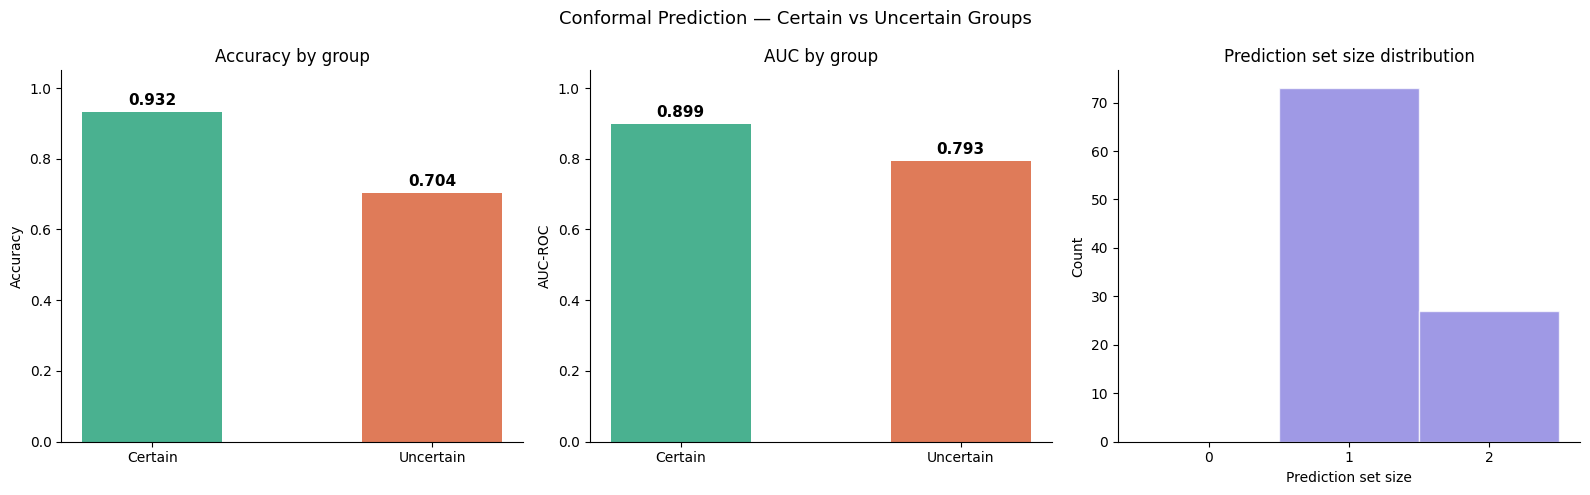

In [97]:
# Group metrics

def group_metrics(df, name):

    acc = df['correct'].mean()

    auc = (
        roc_auc_score(df['true_label'], df['mean_pred'])
        if df['true_label'].nunique() > 1
        else float('nan')
    )

    mean_set_size = df['set_size'].mean()

    mean_nc = df['nonconf_score'].mean()

    coverage = df['covered'].mean()

    return {
        'Group'            : name,
        'N Cases'          : len(df),
        'Accuracy'         : acc,
        'AUC-ROC'          : auc,
        'Coverage'         : coverage,
        'Mean Set Size'    : mean_set_size,
        'Mean NC Score'    : mean_nc,
    }

certain_metrics   = group_metrics(certain, 'Certain')
uncertain_metrics = group_metrics(uncertain, 'Uncertain')

summary_df = pd.DataFrame([
    certain_metrics,
    uncertain_metrics
])

summary_display = summary_df.copy()

for col in ['Accuracy', 'AUC-ROC',
            'Coverage', 'Mean Set Size',
            'Mean NC Score']:

    summary_display[col] = (
        summary_display[col]
        .map(lambda x: f'{x:.4f}')
    )

print('\n📋 Certain vs Uncertain summary')
display(summary_display)

# Statistical comparison

acc_cert   = certain_metrics['Accuracy']
acc_uncert = uncertain_metrics['Accuracy']

auc_cert   = certain_metrics['AUC-ROC']
auc_uncert = uncertain_metrics['AUC-ROC']

# Accuracy comparison

stat_acc, p_acc = proportions_ztest(
    [
        int(acc_cert * len(certain)),
        int(acc_uncert * len(uncertain))
    ],
    [
        len(certain),
        len(uncertain)
    ]
)

print('\n📈 Statistical tests')
print('Z-test: accuracy(certain) > accuracy(uncertain)?')
print(f'Z statistic : {stat_acc:.3f}')
print(f'p-value     : {p_acc:.4f}')

# Nonconformity score comparison

nc_correct = results.loc[
    results['correct'] == 1,
    'nonconf_score'
].values

nc_wrong = results.loc[
    results['correct'] == 0,
    'nonconf_score'
].values

if len(nc_wrong) > 0 and len(nc_correct) > 0:

    stat_nc, p_nc = stats.mannwhitneyu(
        nc_correct,
        nc_wrong,
        alternative='less'
    )

    print('\nMann-Whitney U test:')
    print('nonconformity(correct) < nonconformity(wrong)?')

    print(f'U statistic : {stat_nc:.2f}')
    print(f'p-value     : {p_nc:.4f}')

# Visual comparison plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    'Conformal Prediction — Certain vs Uncertain Groups',
    fontsize=13
)

groups = ['Certain', 'Uncertain']
colors = ['#1D9E75', '#D85A30']

# Accuracy comparison

axes[0].bar(
    groups,
    [acc_cert, acc_uncert],
    color=colors,
    alpha=0.8,
    width=0.5
)

axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by group')

for i, v in enumerate([acc_cert, acc_uncert]):

    axes[0].text(
        i,
        v + 0.02,
        f'{v:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

axes[0].spines[['top', 'right']].set_visible(False)

# AUC comparison

axes[1].bar(
    groups,
    [auc_cert, auc_uncert],
    color=colors,
    alpha=0.8,
    width=0.5
)

axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC by group')

for i, v in enumerate([auc_cert, auc_uncert]):

    axes[1].text(
        i,
        v + 0.02,
        f'{v:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

axes[1].spines[['top', 'right']].set_visible(False)

# Prediction set size distribution

axes[2].hist(
    results['set_size'],
    bins=np.arange(-0.5, 3.5, 1),
    color='#7F77DD',
    alpha=0.75,
    edgecolor='white'
)

axes[2].set_xticks([0, 1, 2])
axes[2].set_xlabel('Prediction set size')
axes[2].set_ylabel('Count')
axes[2].set_title('Prediction set size distribution')

axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Samples classified as certain achieve substantially higher performance (accuracy 0.932, AUC 0.899) than uncertain samples (accuracy 0.704, AUC 0.793), indicating that the model's uncertainty is well aligned with its likelihood of error. The prediction set size distribution reinforces this interpretation: most examples receive a singleton prediction set, reflecting high confidence, while a smaller subset receives larger prediction sets, signaling ambiguity and prompting greater caution. Rather than treating all predictions equally, conformal prediction identifies cases where the model is less reliable and appropriately expresses that uncertainty through expanded prediction sets.

---
## 🏥 Part 7 — Medical visualisation

We present two most certain and two most uncertain cases from the test set

In [98]:
LABEL_NAMES = {0: 'Normal', 1: 'Pneumonia'}

# Visualisation helper

def tensor_to_display(x):

    # first channel
    img = x[0].numpy()

    # rotate 90° clockwise
    img = np.rot90(img, k=-1)

    # mirror flip
    img = np.fliplr(img)

    return np.clip(img, 0, 1)


def plot_cp_group(indices, results_df, images_list,
                  group_title, n_show=2):

    indices = list(indices)[:n_show]

    if not indices:
        print(f'No cases: {group_title}')
        return

    fig, axes = plt.subplots(
        1,
        len(indices),
        figsize=(5 * len(indices), 6)
    )

    if len(indices) == 1:
        axes = [axes]

    fig.suptitle(
        group_title,
        fontsize=13,
        fontweight='bold',
        y=1.02
    )

    for ax, idx in zip(axes, indices):

        row = results_df.loc[idx]

        img = tensor_to_display(images_list[idx])

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        pred_set_names = [
            LABEL_NAMES[k]
            for k in row['pred_set']
        ]

        covered_str = (
            '✓ Covered'
            if row['covered']
            else '✗ Not covered'
        )

        correct_str = (
            '✓ Correct'
            if row['correct']
            else '✗ Wrong'
        )

        # Red if wrong OR non-singleton set
        is_uncertain = row['set_size'] > 1

        title_color = (
            '#D62728'
            if (not row['correct']) or is_uncertain
            else '#1D9E75'
        )
        
        pred_set_text = (
            f'⚠️ Pred set: {{{", ".join(pred_set_names)}}}'
            if is_uncertain
            else f'Pred set: {{{", ".join(pred_set_names)}}}'
        )

        title = (
            f'{correct_str} | {covered_str}\n'
            f'True: {LABEL_NAMES[int(row["true_label"])]}\n'
            f'{pred_set_text}\n'
            f'Set size: {row["set_size"]}\n'
            f'P(pneu): {row["mean_pred"]:.2f}\n'
        )

        ax.set_title(
            title,
            fontsize=8.5,
            color=title_color,
            pad=5
        )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57/97976582.py:100: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


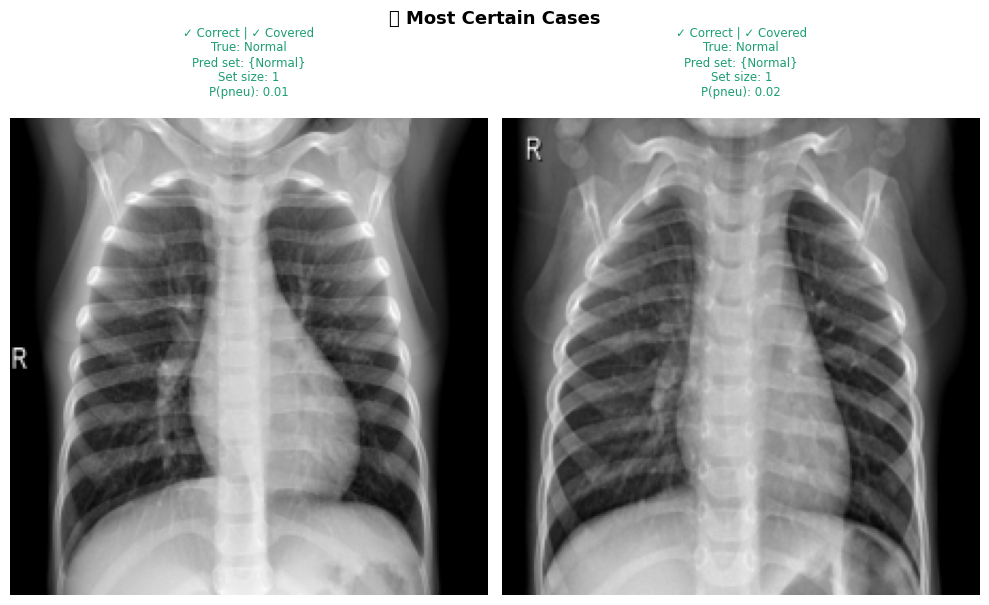

In [99]:
# MOST CERTAIN CASES

most_certain_idx = (
    results[results['set_size'] == 1]
    .nsmallest(2, 'nonconf_score')
    .index.tolist()
)

plot_cp_group(
    most_certain_idx,
    results,
    test_images,
    '🟢 Most Certain Cases'
)

/tmp/ipykernel_57/97976582.py:100: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


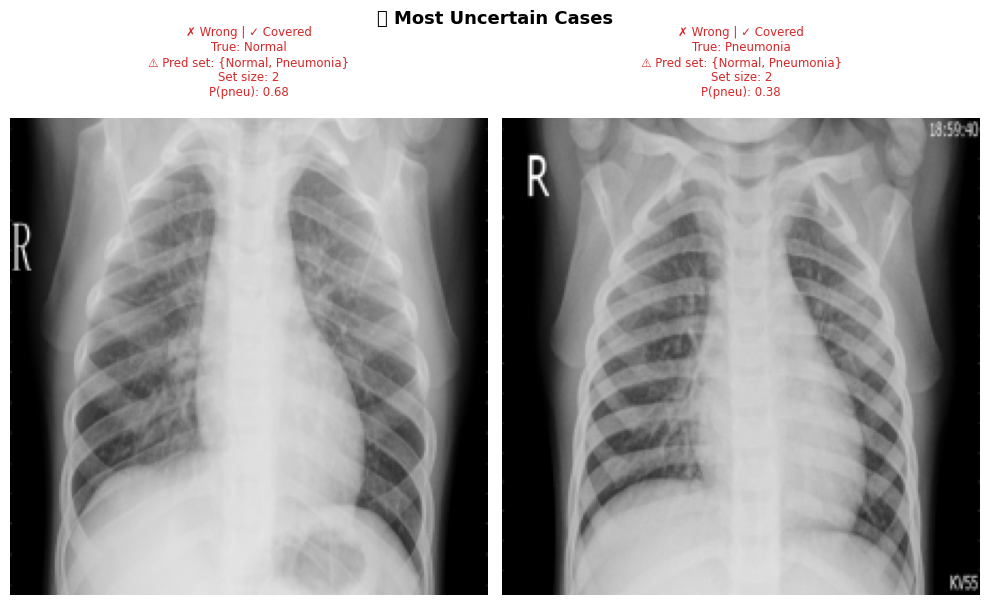

In [100]:
# MOST UNCERTAIN CASES

most_uncertain_idx = (
    results[results['set_size'] != 1]
    .nlargest(2, 'nonconf_score')
    .index.tolist()
)

plot_cp_group(
    most_uncertain_idx,
    results,
    test_images,
    '🔴 Most Uncertain Cases'
)

---
## 💾 Part 9 — Save results

In [101]:
results['method'] = 'CP'

save_path = '/kaggle/working/results_cp.csv'
results.to_csv(save_path, index=False)

print(f'Results saved to: {save_path}')

Results saved to: /kaggle/working/results_cp.csv


---
## ✅ Session summary

| Step               | What we did                                                                             |
| ------------------ | --------------------------------------------------------------------------------------- |
| 🗂️ Data           | MONAI preprocessing + controlled subsampling preserving class imbalance                 |
| 🧠 Model           | DenseNet121 (ImageNet pretrained) with cross-entropy training                           |
| ⚙️ CP setup        | Split conformal via held-out calibration set → prediction sets with (1-alpha) coverage |
| 📊 Base eval       | Accuracy + AUC-ROC on test set                                                          |
| 📦 Prediction sets | Singleton / multi-label / empty sets based on confidence                                |
| ⚖️ Analysis        | Compared certain (singleton) vs uncertain (multi-label/full) cases                               |
| 🏥 Visualization   | Most certain and most uncertain X-rays                                                  |

---

> **➡️ Next: Session 15: Part 2 summary**  
> All methods — VI, MC Dropout, Deep Ensembles, EDL, and CP — compared side by side. The comparison notebook helps determine when each uncertainty method is most appropriate to use.